In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

In [2]:
from PIL import Image
import os
import xml.etree.ElementTree as ET

drive_path = os.path.join(os.getcwd(), "../dataset")

# Paths to your dataset
dataset_dir = drive_path + '/filtered/Image'

for cls in os.listdir(dataset_dir):
  for img in os.listdir(dataset_dir + "/" + cls):
    image_file = dataset_dir + "/" + cls + "/" + img
    image = Image.open(image_file)
    annomation = image_file.replace("/Image", "/Annotation")
    annomation = annomation.replace(".jpg", "")
    tree = ET.parse(annomation)
    root = tree.getroot()
    bndbox = root.find(".//bndbox")  # Locate the <bndbox> tag
    xmin = int(bndbox.find("xmin").text)
    ymin = int(bndbox.find("ymin").text)
    xmax = int(bndbox.find("xmax").text)
    ymax = int(bndbox.find("ymax").text)

    crop_coords = (xmin, ymin, xmax, ymax)  # (x_min, y_min, x_max, y_max)

    cropped_image = image.crop(crop_coords)
    cropped_folder = image_file.split("/Image")[0] + "/ImageCropped/" + cls
    if not os.path.exists(cropped_folder):
      os.mkdir(cropped_folder)
    cropped_filepath = cropped_folder + "/" + img
    cropped_image.save(cropped_filepath)


In [3]:
drive_path = os.path.join(os.getcwd(), "../dataset")

# Paths to your dataset
dataset_dir = drive_path + '/filtered/ImageCropped'


# Data Augmentation
datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    dataset_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

val_generator = datagen.flow_from_directory(
    dataset_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',  # Specify this as validation data
    shuffle=False
)


Found 1963 images belonging to 12 classes.
Found 389 images belonging to 12 classes.


In [4]:
class_indices = train_generator.class_indices
class_names = {v: k for k, v in class_indices.items()}

from collections import Counter

class_counts = Counter(train_generator.classes)
total_data_per_class = {class_names[k]: v for k, v in class_counts.items()}

train_histogram = {}
for class_name, count in total_data_per_class.items():
  train_histogram[class_name.split("-")[1]] = count
# print(train_histogram)

sorted_train_histogram = sorted(train_histogram.items(), key=lambda x: x[0], reverse=True)
# print(sorted_train_histogram, type(sorted_train_histogram))


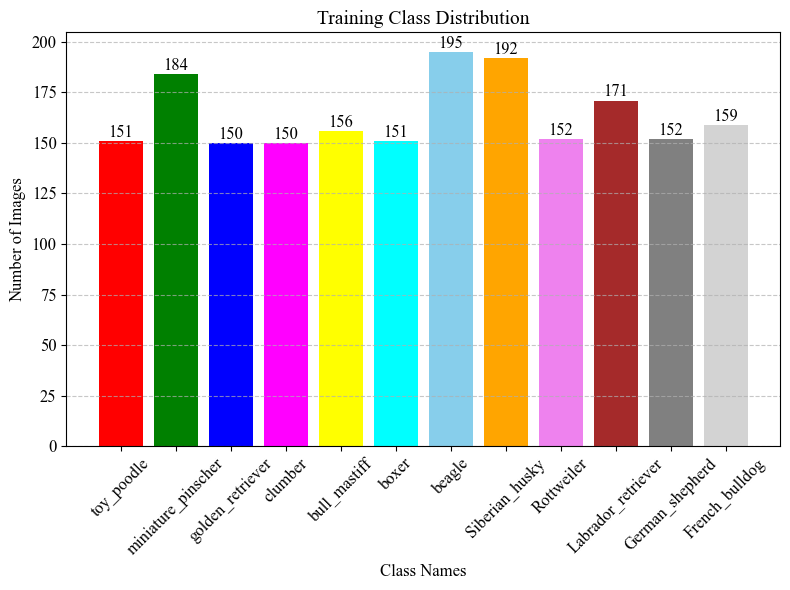

In [87]:
import matplotlib.pyplot as plt

# Class distribution data
class_names = []
class_counts = []
for item in sorted_train_histogram:
  class_names.append(item[0])
  class_counts.append(item[1])


# Plot the bar chart
plt.figure(figsize=(8, 6))
plt.rcParams['font.family'] = 'Times New Roman'
bars = plt.bar(class_names, class_counts, color=['red', 'green', 'blue', 'magenta', 'yellow', 'cyan', 'skyblue', 'orange', 'violet', 'brown', 'gray', 'lightgray'])

# Add labels and title

plt.title('Training Class Distribution', fontsize=14)
plt.xlabel('Class Names', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

# Annotate bar values
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 2, str(yval), ha='center', fontsize=12)
image_path = os.path.join(os.getcwd(), "../train_data.png")
plt.tight_layout()
plt.savefig(image_path)
plt.show()

In [6]:
class_indices = val_generator.class_indices
class_names = {v: k for k, v in class_indices.items()}

from collections import Counter

class_counts = Counter(val_generator.classes)
total_data_per_class = {class_names[k]: v for k, v in class_counts.items()}

val_histogram = {}
for class_name, count in total_data_per_class.items():
  val_histogram[class_name.split("-")[1]] = count
# print(val_histogram)

sorted_val_histogram = sorted(val_histogram.items(), key=lambda x: x[0], reverse=True)
# print(sorted_val_histogram, type(sorted_val_histogram))

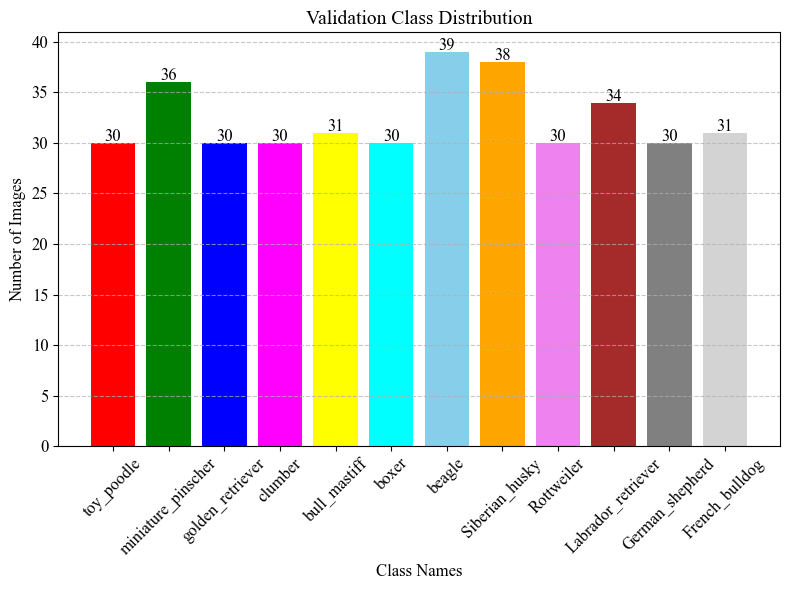

In [88]:
import matplotlib.pyplot as plt

# Class distribution data
class_names = []
class_counts = []
for item in sorted_val_histogram:
  class_names.append(item[0])
  class_counts.append(item[1])


# Plot the bar chart
plt.figure(figsize=(8, 6))
plt.rcParams['font.family'] = 'Times New Roman'
bars = plt.bar(class_names, class_counts, color=['red', 'green', 'blue', 'magenta', 'yellow', 'cyan', 'skyblue', 'orange', 'violet', 'brown', 'gray', 'lightgray'])

# Add labels and title

plt.title('Validation Class Distribution', fontsize=14)
plt.xlabel('Class Names', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

# Annotate bar values
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.2, str(yval), ha='center', fontsize=12)
image_path = os.path.join(os.getcwd(), "../val_data.png")
plt.tight_layout()
plt.savefig(image_path)
plt.show()

In [8]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications import NASNetLarge
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

def create_model(base_model_type='InceptionV3', num_classes=120):  # Adjust classes based on breeds
    if base_model_type == 'InceptionV3':
        base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    elif base_model_type == 'NASNetLarge':
        base_model = NASNetLarge(weights='imagenet', include_top=False, input_shape=(331, 331, 3))
    else:
        raise ValueError("Unsupported base model type.")

    # Add custom layers for breed-specific classification
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)

    # Freeze base model layers
    for layer in base_model.layers:
        layer.trainable = False

    return model

model = create_model(base_model_type='InceptionV3', num_classes=12)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [96]:
# model.summary()

In [9]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_steps=val_generator.samples // val_generator.batch_size
)


Epoch 1/10
61/61 [==============================] - 35s 453ms/step - loss: 2.6116 - accuracy: 0.4345 - val_loss: 0.3604 - val_accuracy: 0.8984
Epoch 2/10
61/61 [==============================] - 20s 335ms/step - loss: 0.4693 - accuracy: 0.8472 - val_loss: 0.1965 - val_accuracy: 0.9531
Epoch 3/10
61/61 [==============================] - 21s 342ms/step - loss: 0.2977 - accuracy: 0.9011 - val_loss: 0.1364 - val_accuracy: 0.9661
Epoch 4/10
61/61 [==============================] - 21s 338ms/step - loss: 0.2337 - accuracy: 0.9368 - val_loss: 0.1972 - val_accuracy: 0.9245
Epoch 5/10
61/61 [==============================] - 21s 339ms/step - loss: 0.3027 - accuracy: 0.9006 - val_loss: 0.1477 - val_accuracy: 0.9583
Epoch 6/10
61/61 [==============================] - 20s 334ms/step - loss: 0.2242 - accuracy: 0.9291 - val_loss: 0.0923 - val_accuracy: 0.9661
Epoch 7/10
61/61 [==============================] - 21s 336ms/step - loss: 0.1958 - accuracy: 0.9404 - val_loss: 0.1323 - val_accuracy: 0.9583

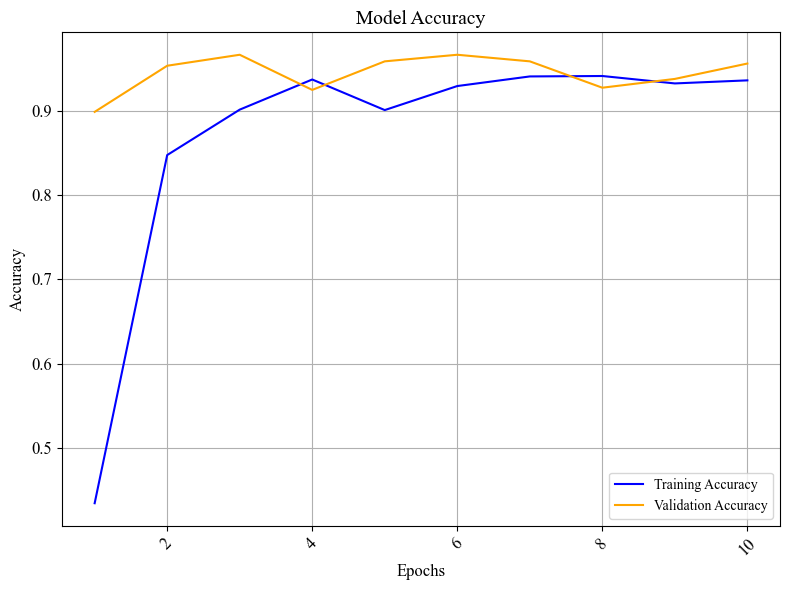

In [89]:
# Extract training and validation accuracy from the history object
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Plot the training and validation accuracy
plt.figure(figsize=(8, 6))
plt.rcParams['font.family'] = 'Times New Roman'
plt.plot(range(1, len(train_acc) + 1), train_acc, label='Training Accuracy', color='blue')
plt.plot(range(1, len(val_acc) + 1), val_acc, label='Validation Accuracy', color='orange')

# Add labels and title

plt.title('Model Accuracy', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

image_path = os.path.join(os.getcwd(), "../train_val_acc.png")
plt.tight_layout()
plt.savefig(image_path)
plt.show()

13/13 [==============================] - 4s 241ms/step


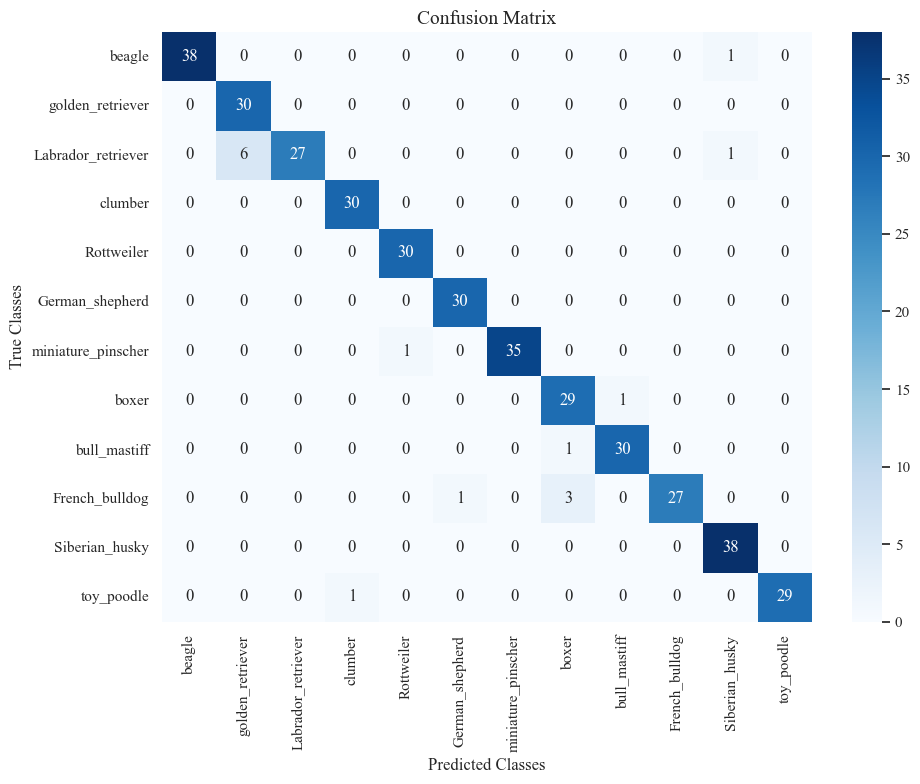

In [27]:
from sklearn.metrics import confusion_matrix
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


y_true = val_generator.classes  # True labels
class_indices = val_generator.class_indices  # Class mapping
classes = list(class_indices.keys())  # Class names
classes = [x.split("-")[1] for x in classes]

# Predict probabilities
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# Generate confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
plt.rcParams['font.family'] = 'Times New Roman'

sns.set(font=fontfam['fontname'])
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Classes', fontsize=12)
plt.ylabel('True Classes', fontsize=12)
plt.title('Confusion Matrix', fontsize=14)
image_path = os.path.join(os.getcwd(), "../conf_mat.png")
plt.tight_layout()
plt.savefig(image_path)
plt.show()

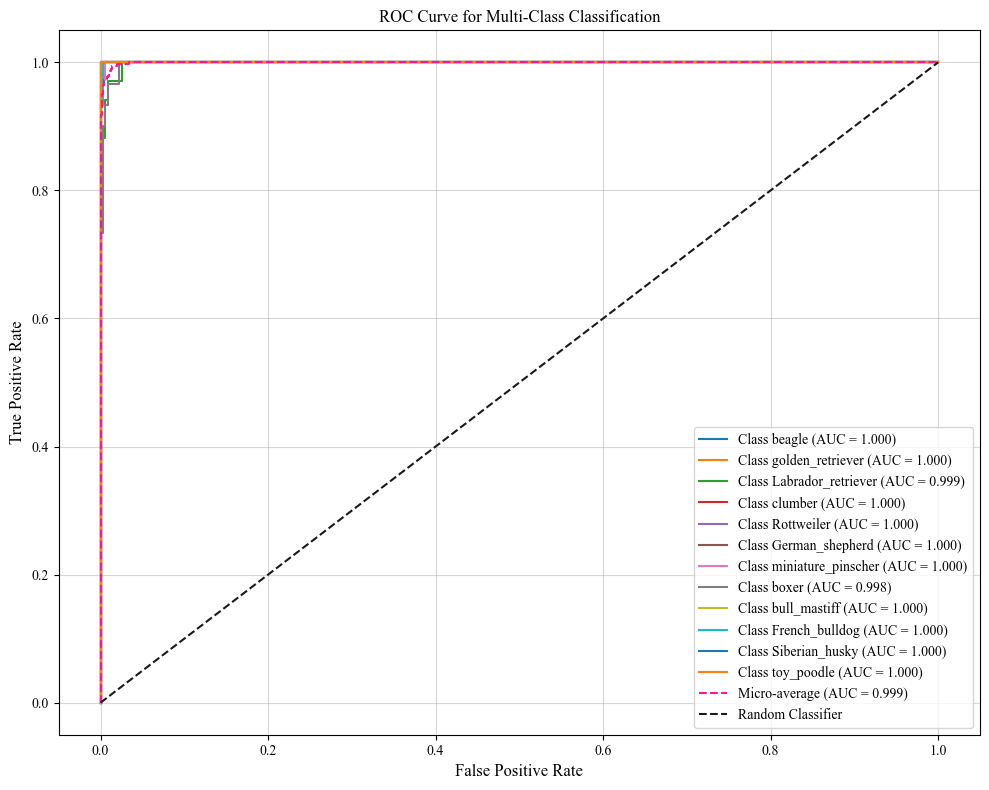

In [86]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the true labels (for multi-class ROC curve)
y_true_binarized = label_binarize(y_true, classes=range(n_classes))

# Compute ROC curve and ROC area for each class
fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(10, 8))
plt.rcParams['font.family'] = 'Times New Roman'

for i in range(12):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'Class {classes[i]} (AUC = {roc_auc[i]:.3f})')

# Micro-average ROC curve and AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_binarized.ravel(), y_pred_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
plt.plot(fpr["micro"], tpr["micro"], linestyle='--', label=f"Micro-average (AUC = {roc_auc['micro']:.3f})", color='deeppink')

# Plot the diagonal line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve for Multi-Class Classification', fontsize=12)
plt.legend(loc='lower right')
plt.grid(alpha=0.5)
# plt.rcParams.update(plt.rcParamsDefault)

image_path = os.path.join(os.getcwd(), "../conf_roc_auc.png")
plt.tight_layout()
plt.savefig(image_path)
plt.show()

1/1 [==============================] - 0s 451ms/step


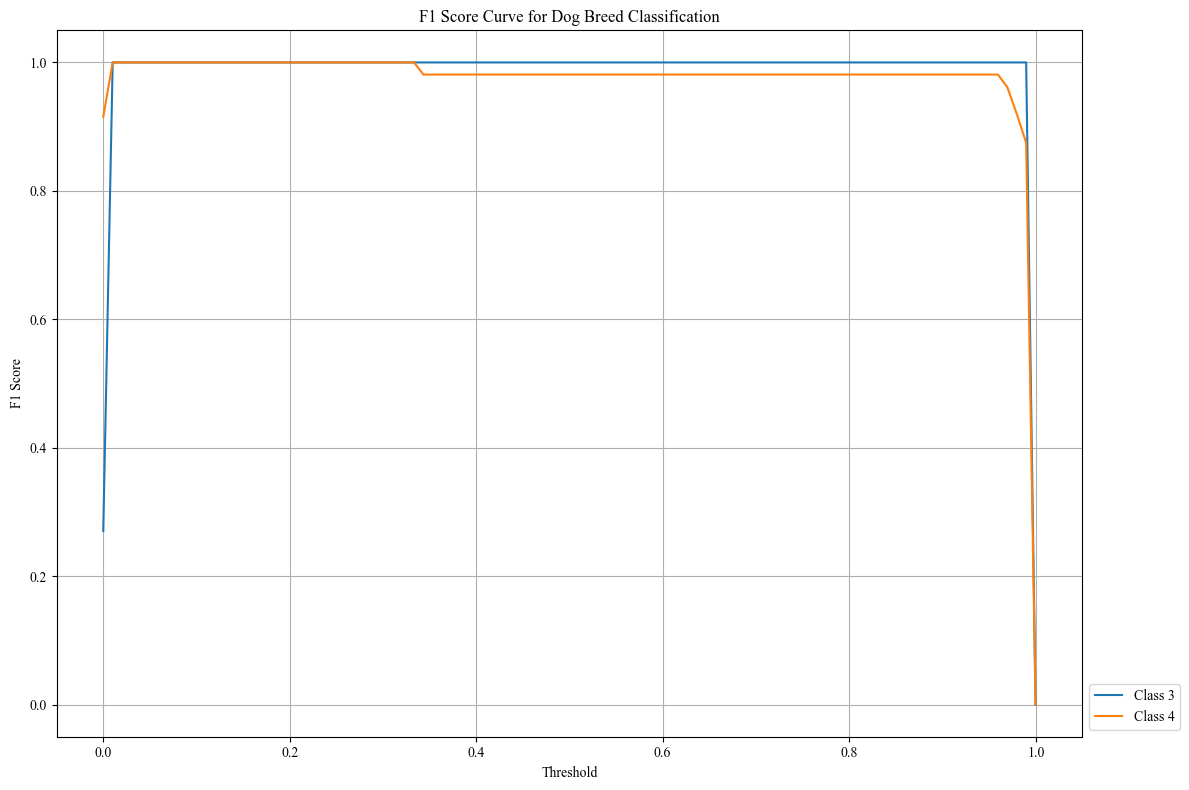

In [94]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, f1_score
from sklearn.preprocessing import label_binarize

# Step 1: Extract y_true and y_pred from val_generator
y_true = []
y_pred = []

for batch_x, batch_y in val_generator:
    y_true.append(batch_y)
    y_pred.append(model.predict(batch_x))
    
    # Stop after one epoch
    if len(y_true) * val_generator.batch_size >= len(val_generator):
        break

# Concatenate all batches
y_true = np.concatenate(y_true, axis=0)
y_pred = np.concatenate(y_pred, axis=0)

# Step 2: Ensure the true labels are binarized for multi-class evaluation
num_classes = y_pred.shape[1]  # Assuming y_pred has shape (samples, 12)
y_true_binarized = label_binarize(y_true, classes=list(range(num_classes)))

# Step 3: Compute F1 score for various thresholds
thresholds = np.linspace(0, 1, 100)
f1_scores = {i: [] for i in range(num_classes)}

for i in range(num_classes):
    # Skip this class if it has no positive examples
    if y_true_binarized[:, i].sum() == 0:
        print(f"Warning: Class {i} has no positive samples in y_true. Skipping.")
        continue

    for t in thresholds:
        pred_class = (y_pred[:, i] >= t).astype(int)
        if pred_class.sum() == 0:
            # Avoid division by zero or undefined F1
            f1_scores[i].append(0.0)
        else:
            f1 = f1_score(y_true_binarized[:, i], pred_class, zero_division=1)
            f1_scores[i].append(f1)

# Step 4: Plot F1 Score Curve
plt.figure(figsize=(12, 8))
for i in range(num_classes):
    if i in f1_scores and len(f1_scores[i]) > 0:
        plt.plot(thresholds, f1_scores[i], label=f'Class {i}')

# Add plot annotations
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score Curve for Dog Breed Classification')
plt.legend(loc='lower left', bbox_to_anchor=(1, 0), ncol=1)
plt.grid()
plt.tight_layout()
plt.show()
